# New York Times Article Analysis
## What Trump Did on Day 1: Tracking His Biggest Moves
### This notebook performs the following analyses:
1. Cleans and preprocesses the article text.
2. Generates a top-20 word frequency bar chart.
3. Creates a word cloud visualization.
4. Conducts sentiment analysis on the article's content.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

# Download stopwords if not available
nltk.download('stopwords')
nltk.download('punkt')

# Manually pasted article text
text = """President Trump made major policy moves immediately after taking office, withdrawing from major international agreements, promising steep tariffs and pardoning nearly all of the Jan. 6 rioters.
President Trump took the oath of office at noon Monday, and within hours he had signed dozens of executive orders and issued nearly 1,600 pardons as he quickly sought to remake the federal government and test the limits of his authority.
His actions touched on some of the biggest policy issues in American life, from health to the environment to immigration, and he promised other consequential changes in the coming days.
Here are eight of the most significant moves the president made on Day 1.

He pardoned nearly all the rioters who stormed the Capitol on Jan. 6.
Mr. Trump issued a sweeping grant of clemency to all of the nearly 1,600 people charged in connection with the Jan. 6, 2021, attack on the Capitol, issuing pardons to most of the defendants and commuting the sentences of 14 members of the Proud Boys and Oath Keepers militia, most of whom were convicted of seditious conspiracy. The pardon order also directed the Justice Department to dismiss any pending indictments against people facing charges for the riot.

He withdrew from the World Health Organization.
Mr. Trump moved to withdraw from the World Health Organization, an act that had been foreshadowed by the president’s frequent attacks against the health agency over its approach to the coronavirus pandemic. Public health experts say that the withdrawal will undermine America’s standing as a global health leader and make it harder to fight the next pandemic.

He began a crackdown on immigration.
A series of orders Mr. Trump signed set off a policy barrage aimed at sealing the nation’s borders to migrants and cracking down on immigrants already in the country. Those orders included a declaration of a national emergency to deploy the military to the border and a bid to cut off birthright citizenship for the children of noncitizens. Many of the orders test the legal limits of his authority, and birthright citizenship in particular is protected by the Constitution.

He sought to put off a ban on TikTok.
Mr. Trump signed an executive order aimed at delaying a federal ban of TikTok. It is unclear if that order could override the law that banned the social media app, but the measure instructs the attorney general not to take any action to enforce the ban for 75 days. Mr. Trump also told reporters that “the U.S. should be entitled to get half of TikTok” if a deal for the app is reached.

He withdrew from the Paris climate agreement.
Mr. Trump signed an executive order to withdraw the United States from the Paris climate agreement, which would make America one of only four nations — along with Iran, Libya and Yemen — not party to the agreement, under which nations work together to reduce global greenhouse gas emissions.

He enacted a federal hiring freeze.
Mr. Trump ordered a hiring freeze across the federal government that would remain in place pending the completion of a broader plan for reducing the federal work force. The order singled out the Internal Revenue Service, which received a large financial boost from President Biden and Democrats in Congress, calling for the freeze to stay in place longer for that agency.

He gutted racial equity policies and protections for transgender people.
Mr. Trump ordered his administration to dismantle federal programs that promote diversity, equity and inclusion, and to gut Biden administration policies that protect transgender Americans.

He promised tariffs against Canada and Mexico.
Mr. Trump said he planned to impose a 25 percent tariff on products from Canada and Mexico starting on Feb. 1 because those nations were allowing “mass numbers of people to come in and fentanyl to come in.” He also said that he “may” impose a universal tariff on all imports, adding that “essentially all countries take advantage of the U.S.”
"""


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:

# Convert text to lowercase and remove special characters
text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and special characters

# Tokenize words and remove stopwords
stop_words = set(stopwords.words('english'))
words = [word for word in text.split() if word not in stop_words]

# Count word frequencies
word_counts = Counter(words)

# Get the top 20 most common words
common_words = word_counts.most_common(20)

# Convert to DataFrame
df_common_words = pd.DataFrame(common_words, columns=["Word", "Frequency"])

# Display word frequencies
df_common_words.head(20)


,Word,Frequency
0,trump,11
1,mr,9
2,federal,6
3,health,6
4,order,5
5,president,4
6,nearly,4
7,signed,4
8,orders,4
9,people,4


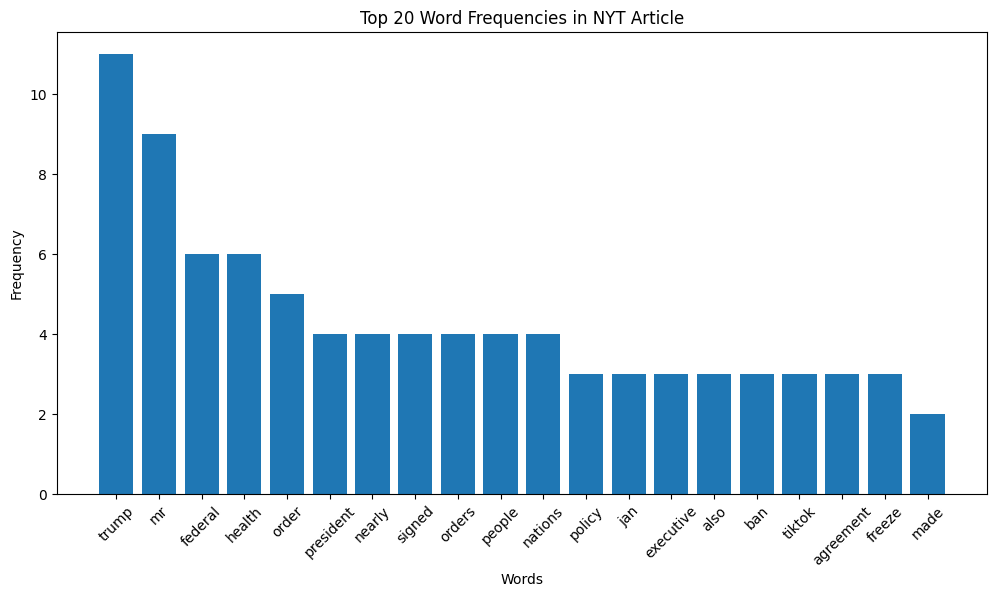

In [3]:

# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(df_common_words["Word"], df_common_words["Frequency"])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Word Frequencies in NYT Article")
plt.xticks(rotation=45)
plt.show()


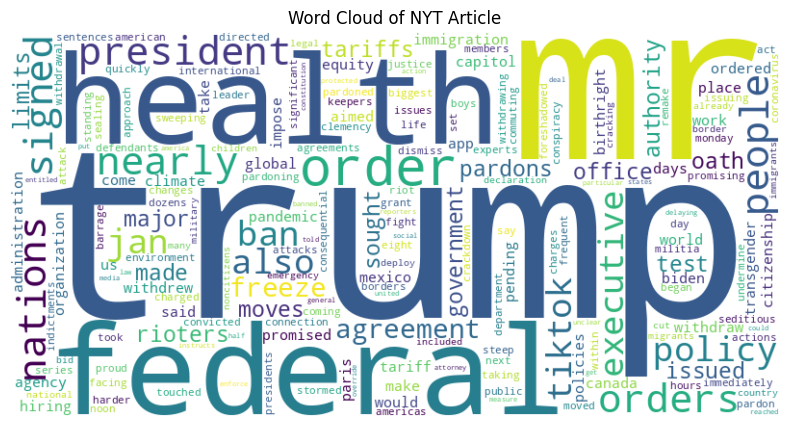

In [4]:

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of NYT Article")
plt.show()


In [5]:

# Perform sentiment analysis
sentiment = TextBlob(text).sentiment

# Display sentiment scores
print(f"Sentiment Polarity: {sentiment.polarity} (Range: -1 to 1, negative to positive)")
print(f"Sentiment Subjectivity: {sentiment.subjectivity} (Range: 0 to 1, objective to subjective)")


Sentiment Polarity: 0.1171157059314954 (Range: -1 to 1, negative to positive)
Sentiment Subjectivity: 0.310547201336675 (Range: 0 to 1, objective to subjective)
